# Visualizing CNN feature maps

This notebook shows how to visualize the feature maps of a convolutional neural network (CNN) using Keras. Feature maps are the outputs of the convolutional layers in a CNN, and visualizing them can help us understand what the network is learning at each layer.

We will be using a pre-trained model available in the Keras framework the VGG16 model, with 16 learned layers. For more information on this model, see the paper <a href="https://arxiv.org/abs/1409.1556">“Very Deep Convolutional Networks for Large-Scale Image Recognition”</a>.

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import Model

#Load the model and print the description of the model
model = VGG16()
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

The `model` object is a Keras model that contains the architecture and weights of the VGG16 model. It allows us to access the layers of the model and extract the feature maps for a given input image. For example, we can access all of the layers of the model via the `model.layers` property.

In [82]:
for layer in model.layers:
    if 'conv' not in layer.name:  # skip the layers that are not convolutional
        continue
    filters, bias = layer.get_weights()
    print(layer.name , filters.shape)

block1_conv1 (3, 3, 3, 64)
block1_conv2 (3, 3, 64, 64)
block2_conv1 (3, 3, 64, 128)
block2_conv2 (3, 3, 128, 128)
block3_conv1 (3, 3, 128, 256)
block3_conv2 (3, 3, 256, 256)
block3_conv3 (3, 3, 256, 256)
block4_conv1 (3, 3, 256, 512)
block4_conv2 (3, 3, 512, 512)
block4_conv3 (3, 3, 512, 512)
block5_conv1 (3, 3, 512, 512)
block5_conv2 (3, 3, 512, 512)
block5_conv3 (3, 3, 512, 512)


The first layer uses 64 filters of size 3x3, and the last layer uses 512 filters of size 3x3. The number of filters in each layer increases as we go deeper into the network, allowing the model to learn more complex features.

Let's visualize the filters of the first convolutional layer. We will use the `get_weights()` method to retrieve the weights of the layer, which are the filters that the model has learned during training. We will then normalize the filter values to a range of 0-1 so that we can visualize them as images.

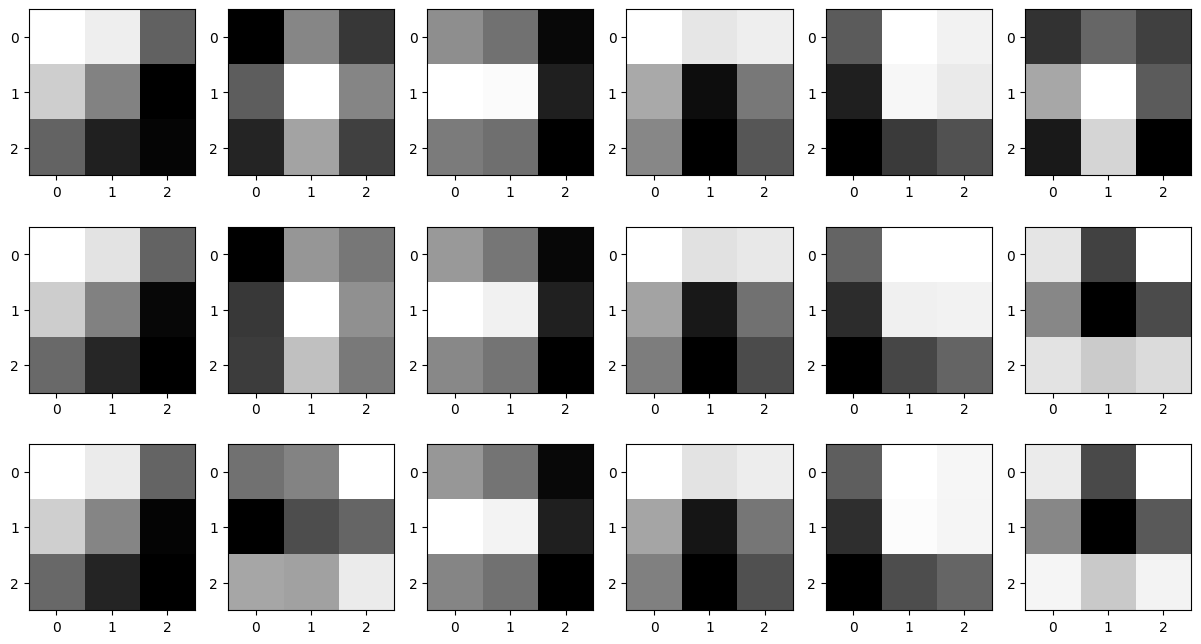

In [83]:
# retrieve weights from the second hidden layer
filters, bias = model.layers[1].get_weights()

# normalize filter values to 0-1 so we can visualize them
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

# plot the first 6 filters
# each column of the plot show a filter, and each row show a channel of the filter
fig = plt.figure(figsize=(15,8))
n_filters=6
for j in range(3):
    for i in range(n_filters):
        # get the filters
        f = filters[:,:,:,i]
        # plot each channel separately
        plt.subplot(3, n_filters, i + 1 + j*n_filters)
        plt.imshow(f[:,:,j] ,cmap='gray')
plt.show()

One can see that many filters have the same values in each channel, which means that they are not learning anything useful. However, some filters have different values in each channel, which means that they are learning to detect different features in the input image.

Let's now visualize the feature maps of the first convolutional layer. **A feature map is the output of a convolutional layer after applying the filters to the input image**. Each feature map corresponds to a specific filter, and it shows how that filter responds to different parts of the input image. Visualizing a feature map for a specific input image allows to understand what features of the input are detected at a given layer. The expectation would be that the feature maps close to the input detect small or fine-grained detail, whereas feature maps close to the output of the model capture more general features.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


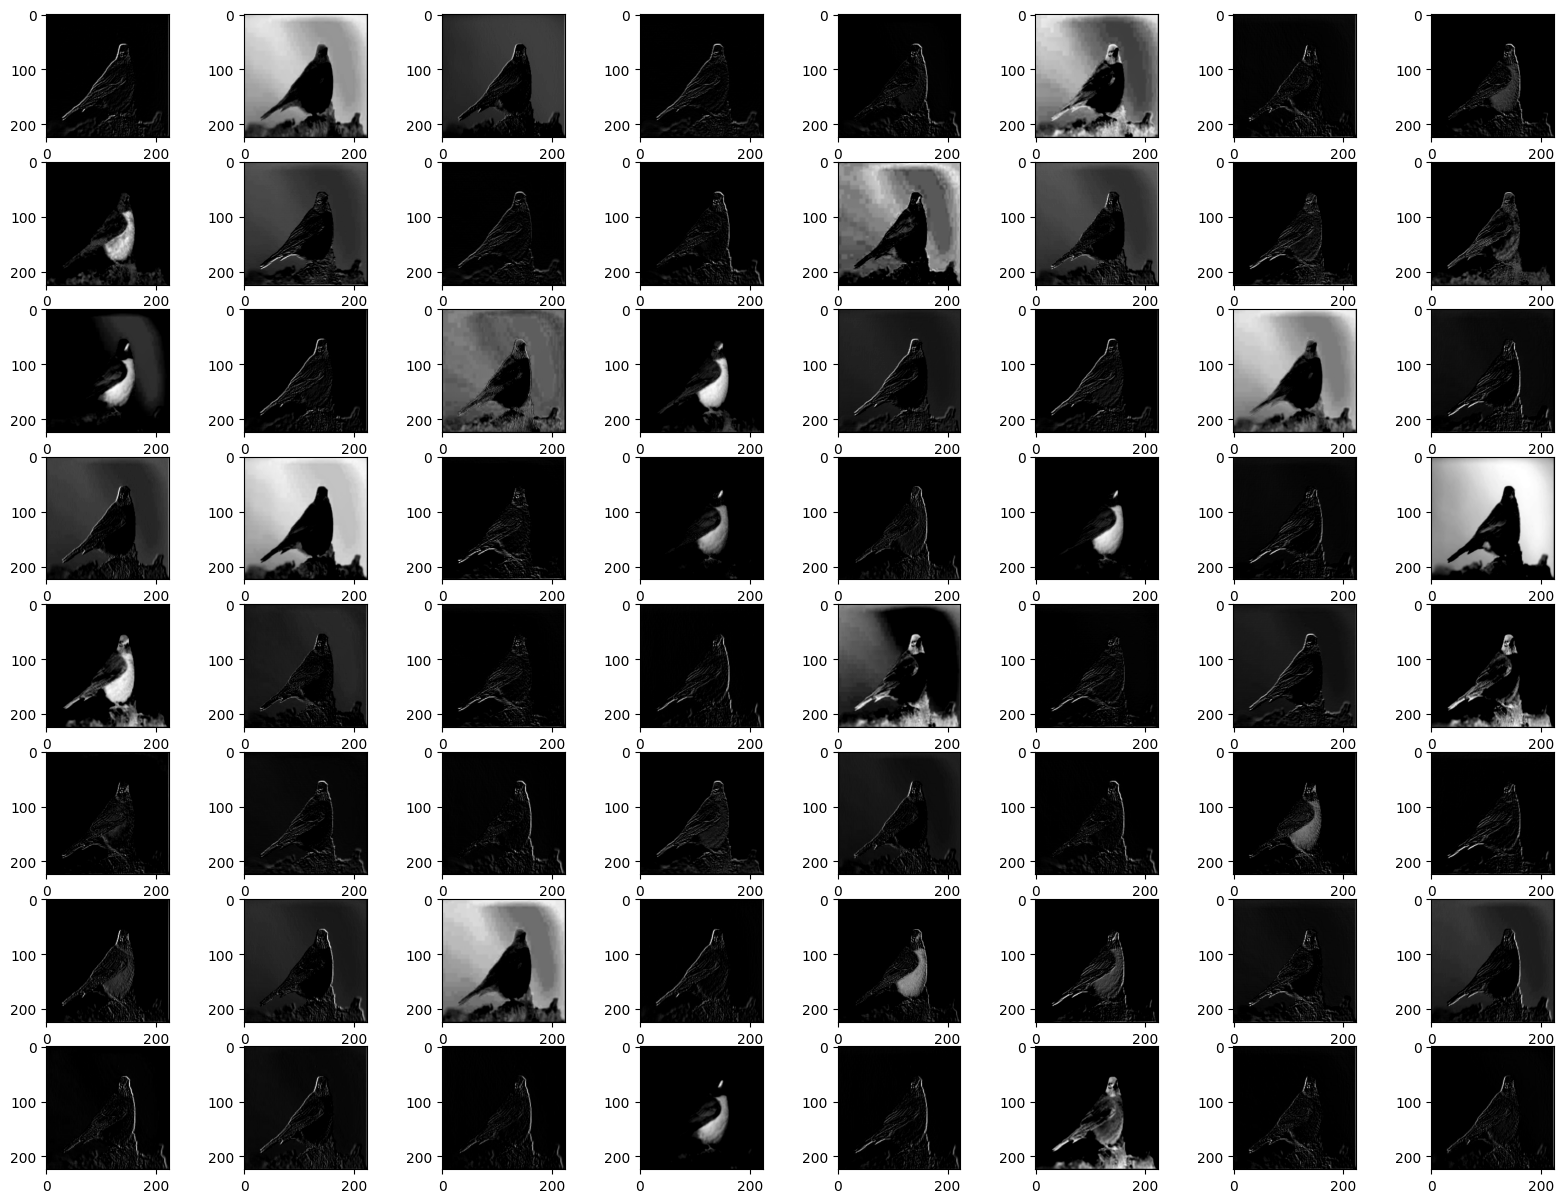

In [84]:
# load the image and convert it to an array
image = load_img("./bird.jpg" , target_size=(224,224))      # load the image and resize it to 224x224 pixels
image = img_to_array(image)                                 # convert the image to a numpy array
image = np.expand_dims(image, axis=0)                       # expand dimensions to match the input shape of the model

# create a new model that outputs the feature maps of the second layer, i.e. the first convolutional layer of the model
# The output of this layer is a 3D tensor with shape (224, 224, 64), where each channel corresponds to a feature map for a specific filter.
layer_model = Model(inputs=model.inputs , outputs=model.layers[1].output)
image = preprocess_input(image)
features = layer_model.predict(image)             # get the feature maps for the input image

# plot the 64 feature maps of the first convolutional layer
fig = plt.figure(figsize=(20,15))
for i in range(1,features.shape[3]+1):
    plt.subplot(8,8,i)
    plt.imshow(features[0,:,:,i-1] , cmap='gray')
plt.show()

One can see that the filters of the first layer are able to detect edges and simple patterns in the input image. As we go deeper into the network, the filters become more complex and are able to detect more abstract features, such as shapes and textures. 

The VGG16 model has 5 convolutional blocks, each containing multiple convolutional layers. The layer indexes of the last convolutional layer in each block are [2, 5, 9, 13, 17]. Let's visualize the 64 first feature maps of each of these layers. 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


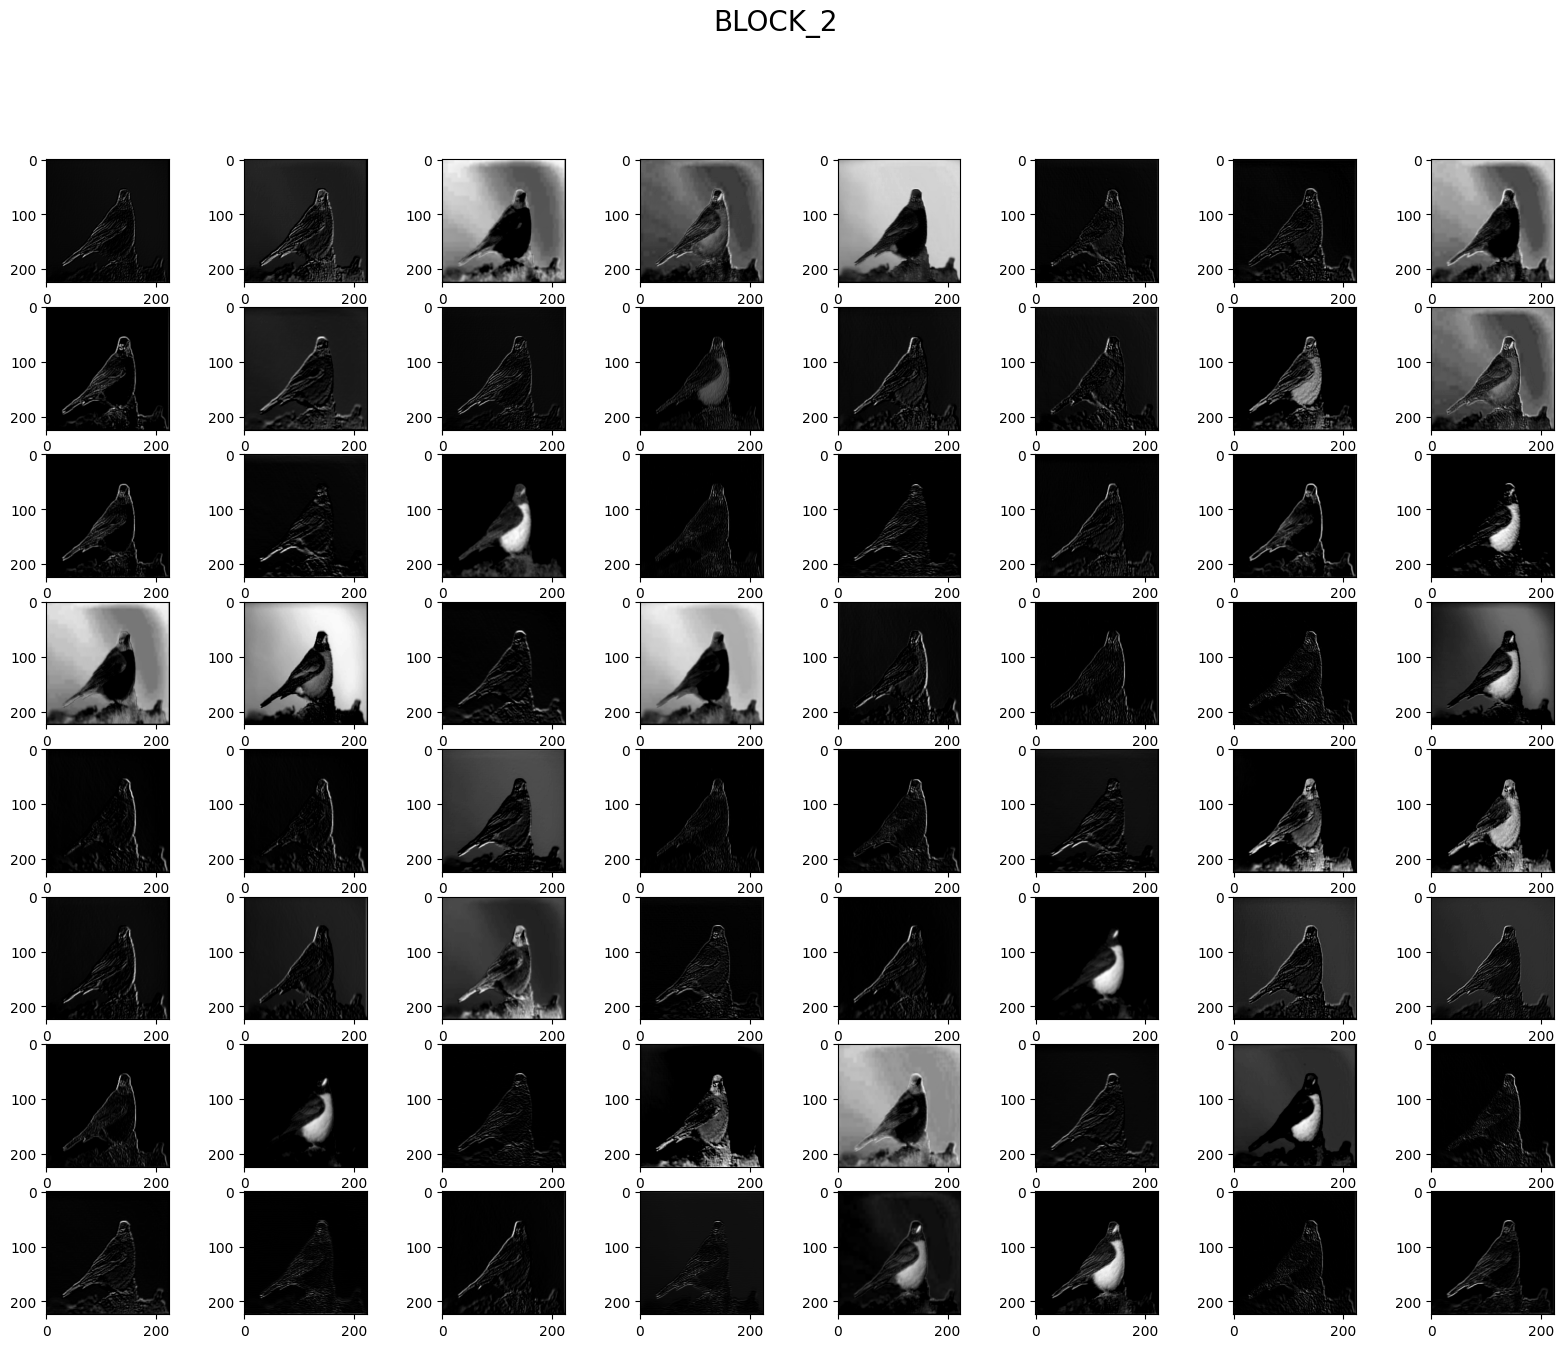

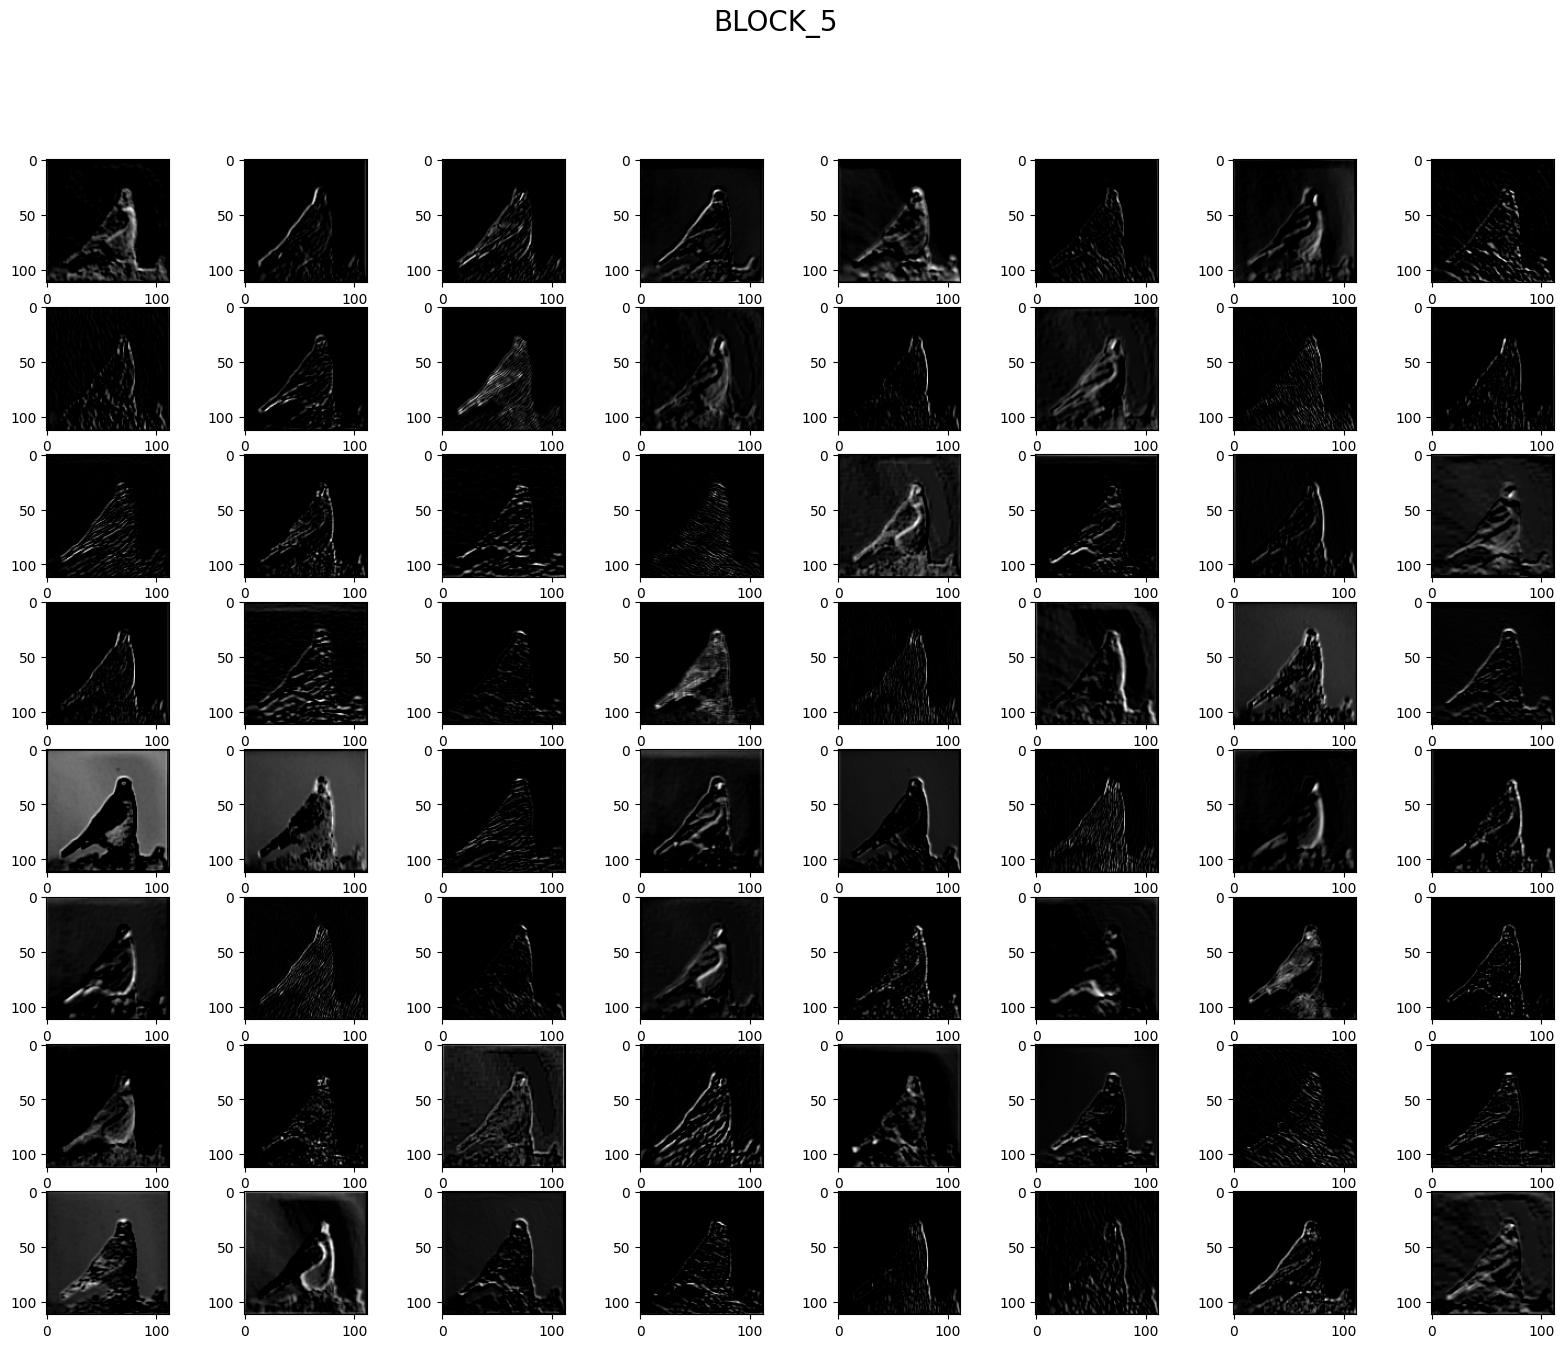

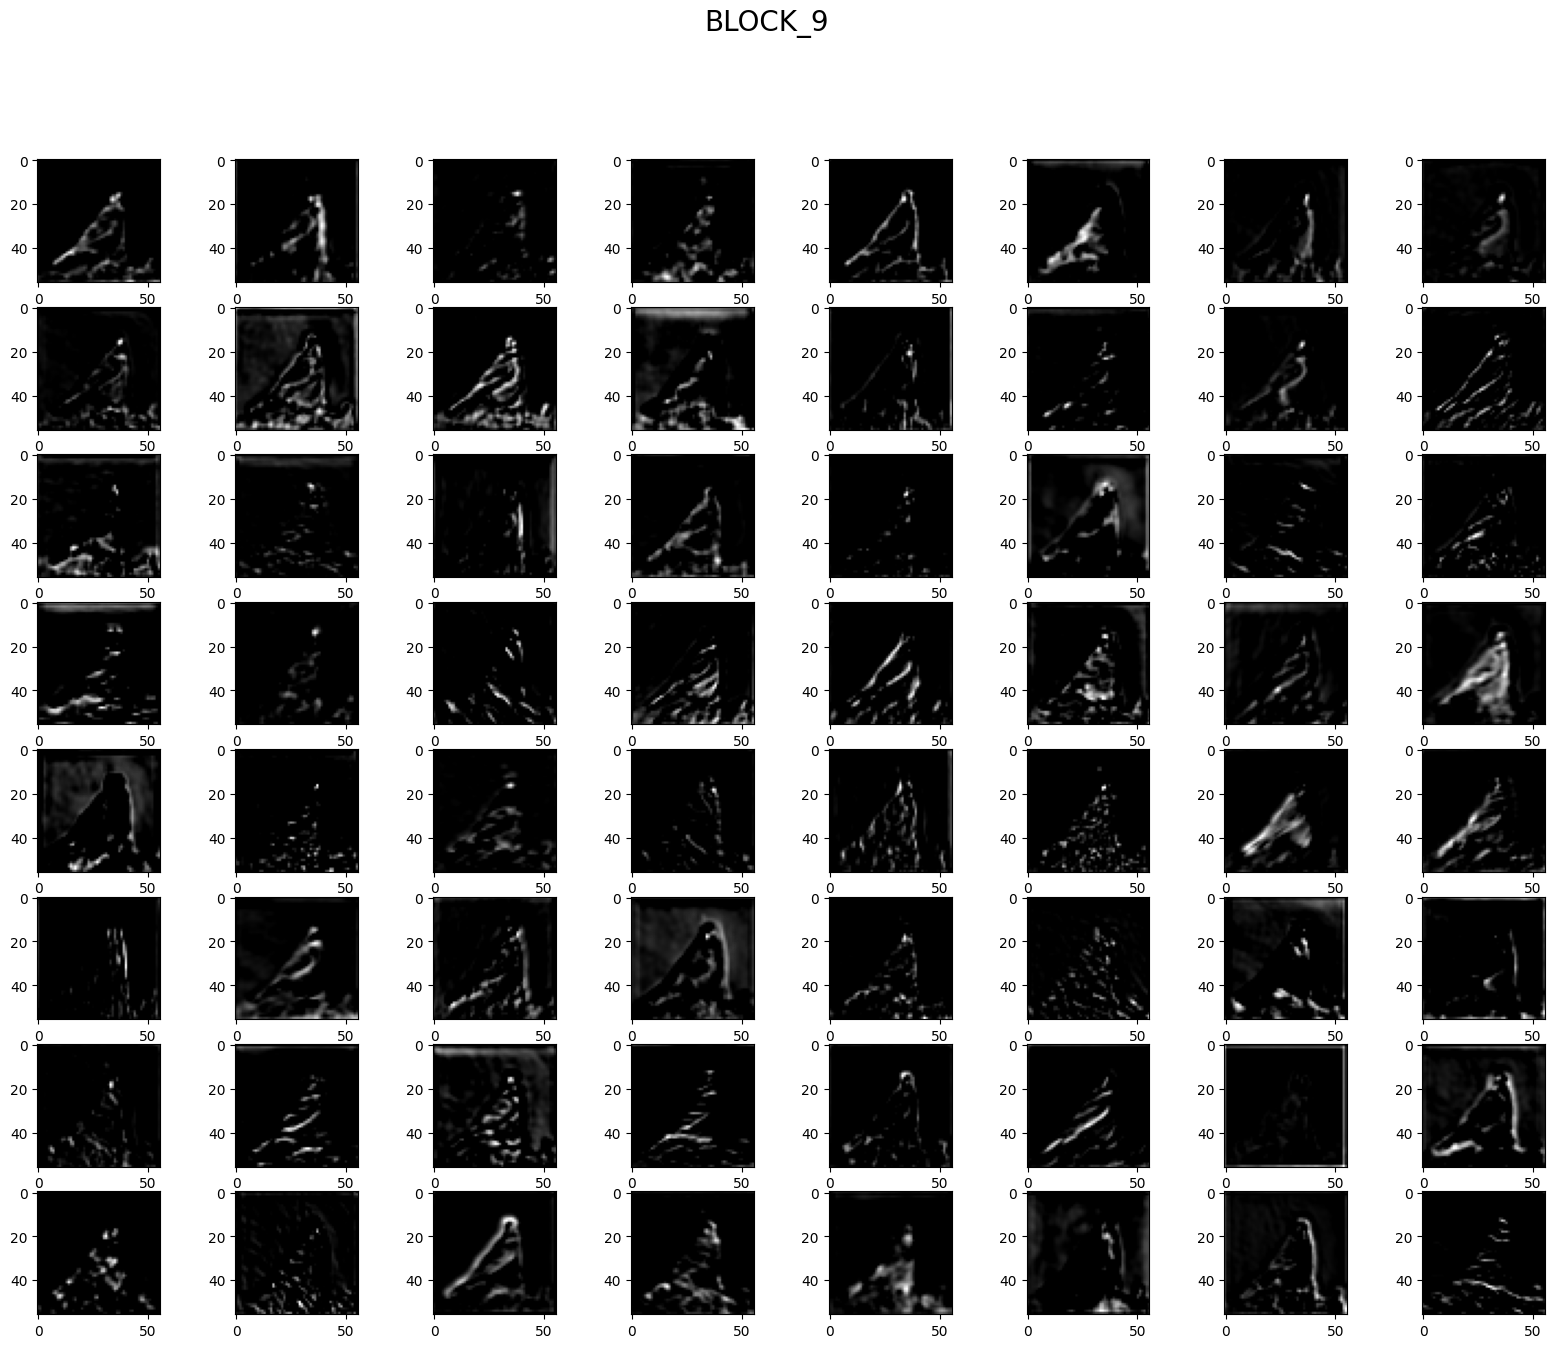

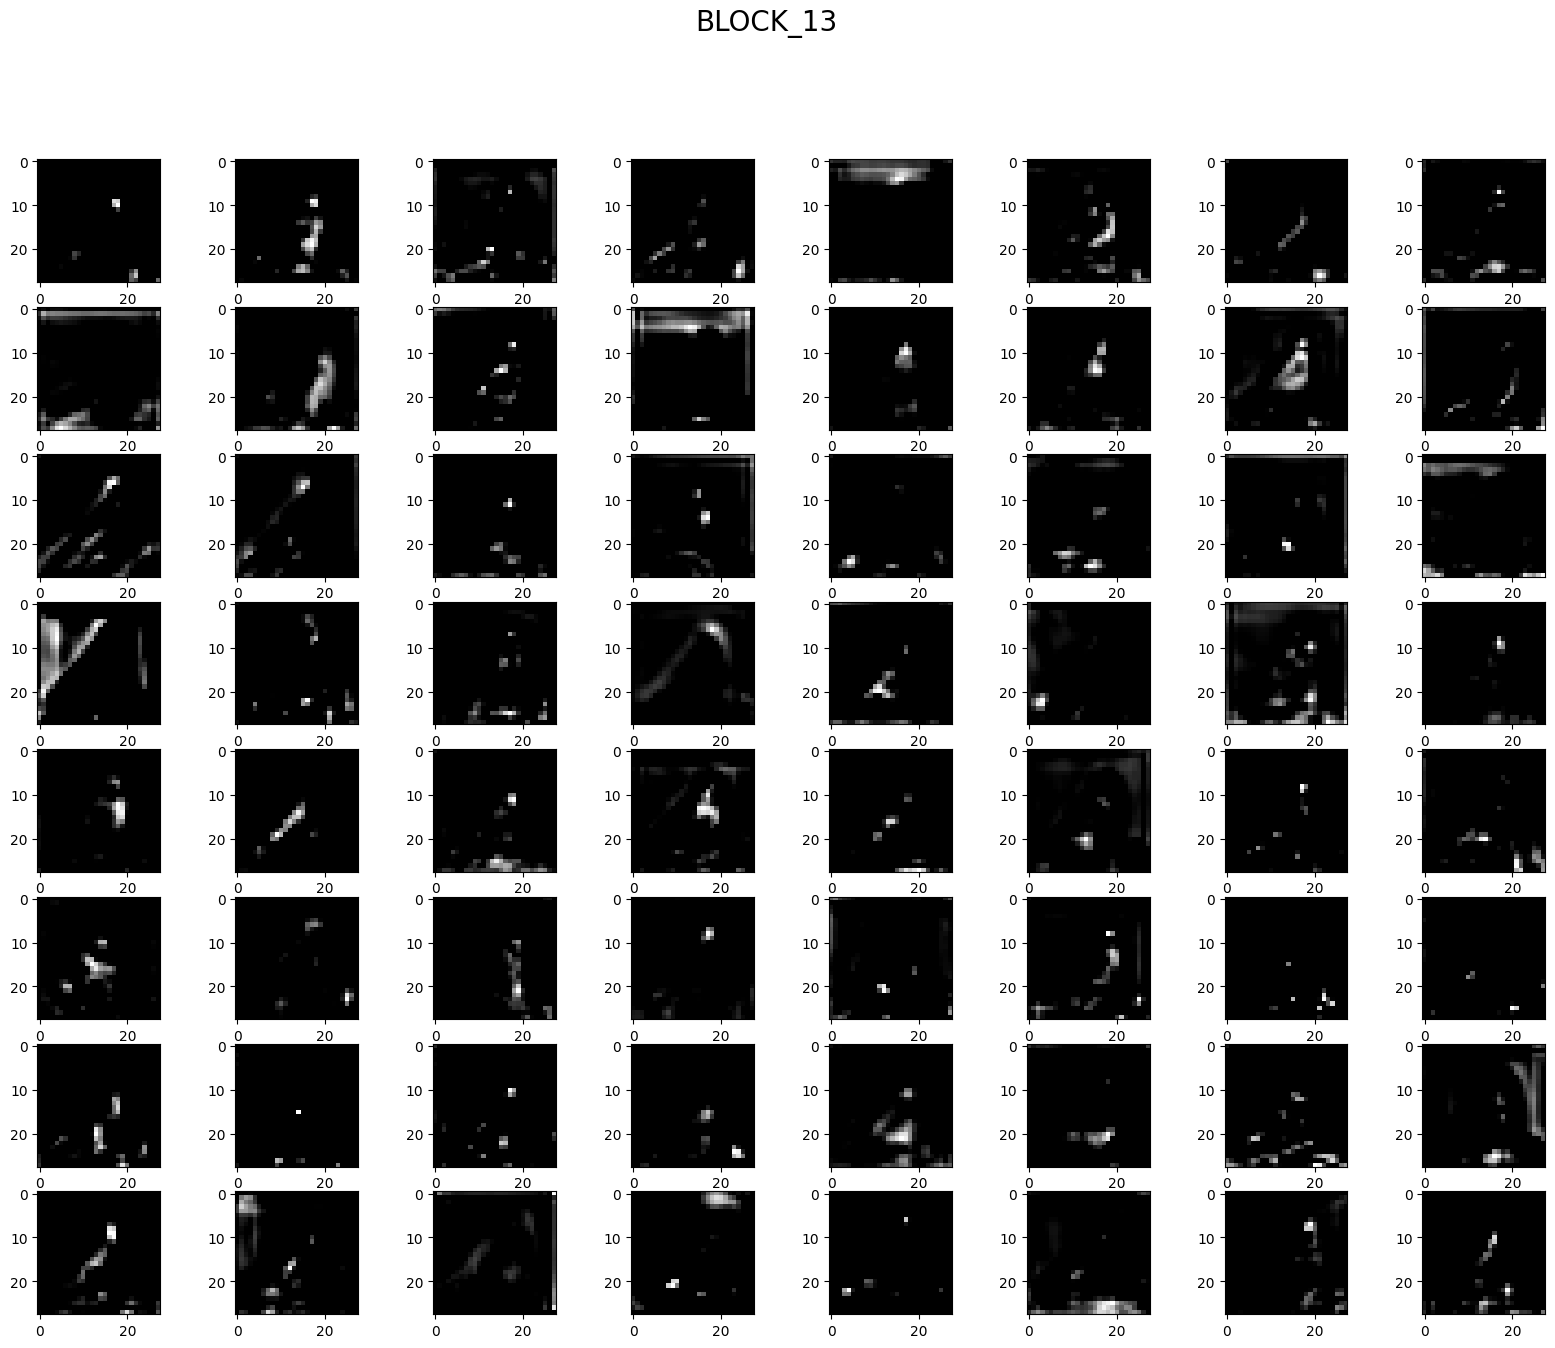

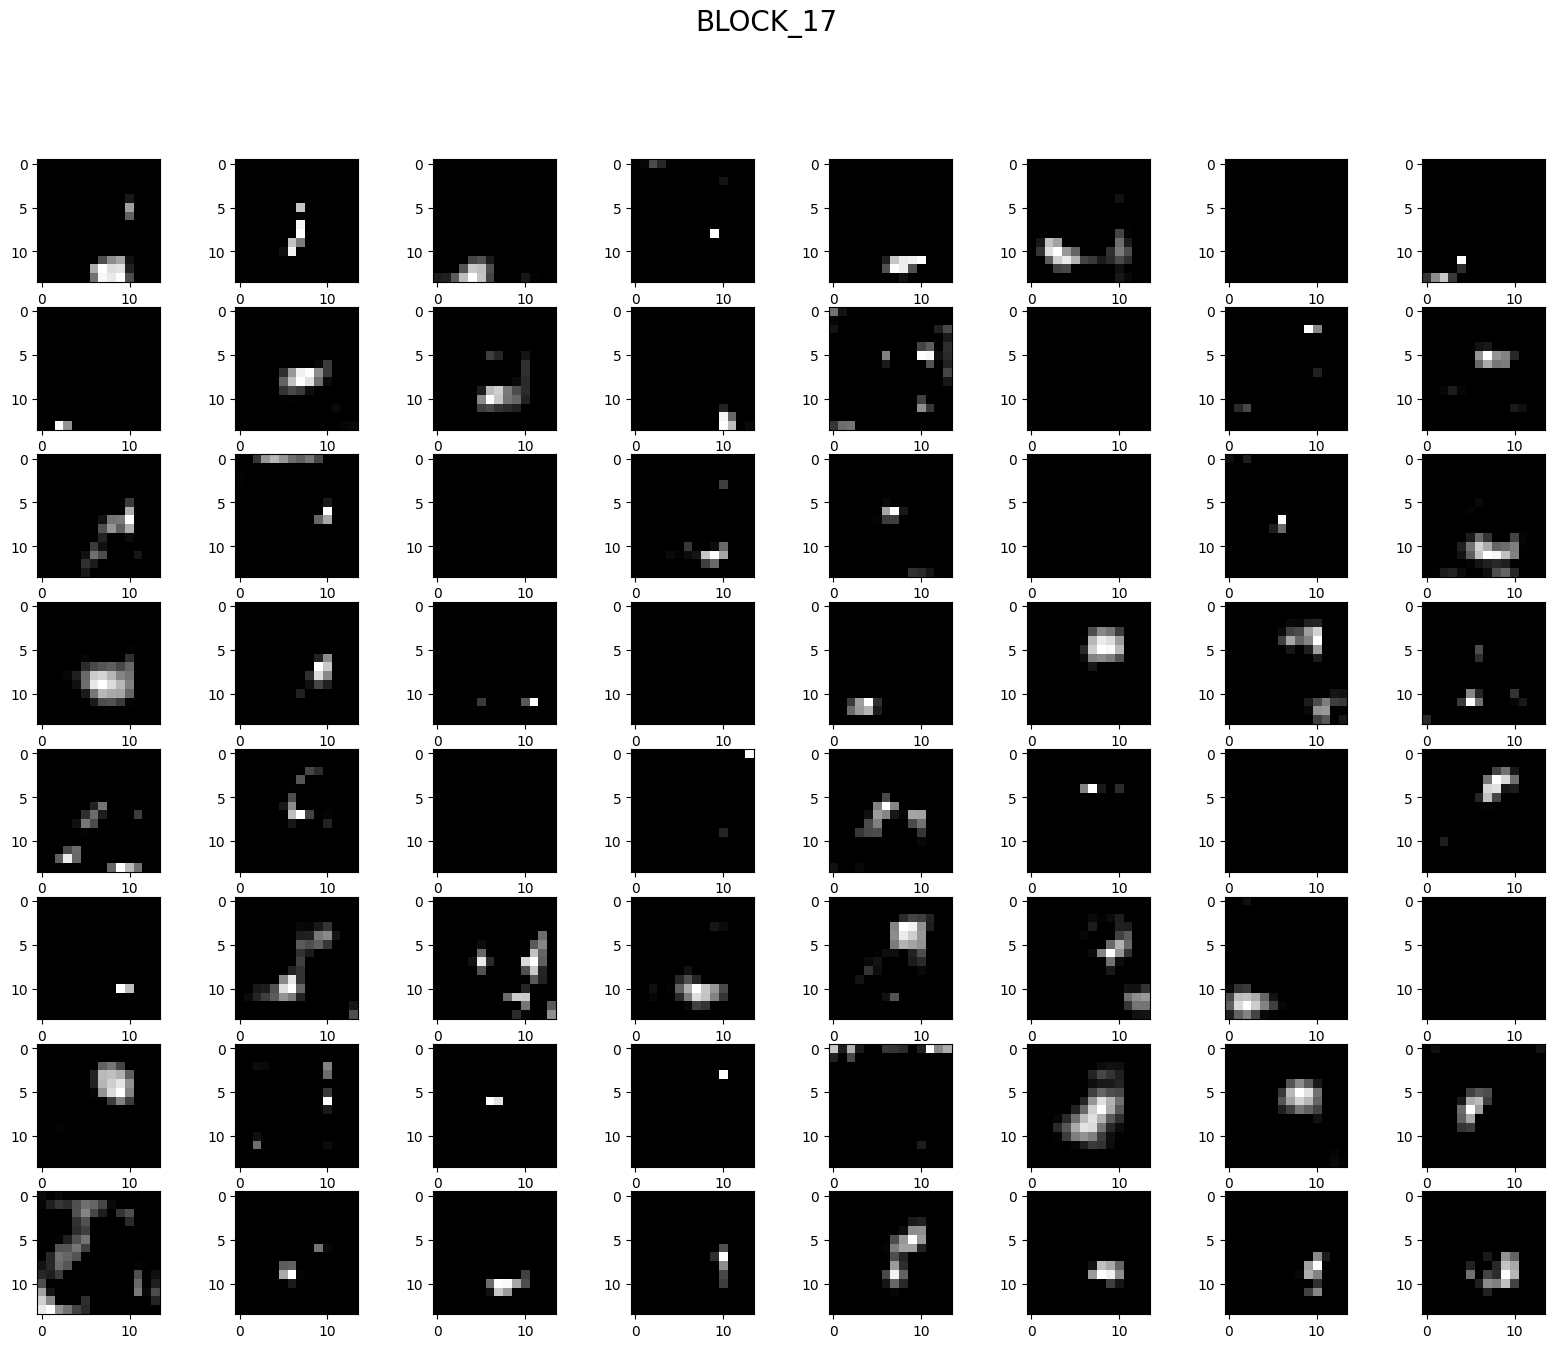

In [85]:
# define the indices of the layers for which to visualize feature maps
idx = [ 2, 5 , 9 , 13 , 17]

# create a new model that outputs the feature maps of the specified layers
outputs = [model.layers[i].output for i in idx]
model = Model(inputs=model.inputs, outputs=outputs)
feature_map = model.predict(image)

# plot the feature maps for each specified layer
for i,fmap in zip(idx, feature_map):
    fig = plt.figure(figsize=(20,15))
    fig.suptitle("BLOCK_{}".format(i), fontsize=20)
    for i in range(1, features.shape[3]+1):
        plt.subplot(8, 8, i)
        plt.imshow(fmap[0,:,:,i-1], cmap='gray')
plt.show()

One can see that the feature maps given by the first block are very close to the input image. This means that the filters of the first block are able to detect low-level features such as edges and textures. As we go deeper into the network, the feature maps become more abstract and less similar to the input image. This means that the filters of the deeper layers are able to detect high-level features such as shapes and objects. The white areas in the feature maps correspond to the parts of the input image that are most strongly activated by the filters. This means that the filters have detected specific features in the input image.

Note that the resolution of the feature maps decreases as we go deeper into the network. This is because the convolutional layers use pooling operations to reduce the spatial dimensions of the feature maps. The pooling operations help to reduce the computational complexity of the model and make it more robust to small translations and distortions in the input image.